# Brain Tumor MRI Classification — MobileNetV2 Transfer Learning

This notebook trains **only a transfer-learning model** for four-class brain MRI classification:
`glioma`, `meningioma`, `notumor`, and `pituitary`.

The MobileNetV2 backbone is pretrained on ImageNet and remains **completely frozen for the entire
training process**. Only the newly added classification head is trained. There is **no fine-tuning**
and no layer of the pretrained backbone is unfrozen.

The `Training` directory is split into stratified train/validation sets, while the `Testing` directory
remains untouched until final evaluation. At the end, the trained model is saved in both modern Keras
`.keras` format and legacy HDF5 `.h5` format.

## 0. Setup

In [4]:
import time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.20.0
GPU available: True


## 1. Paths and Configuration

Same dataset layout as the from-scratch version: a `Training` directory (which we'll split into train +
validation) and a completely untouched `Testing` directory used only for final evaluation.

In [5]:
DATASET_ROOT = Path(
    "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"
)
TRAIN_DIR = DATASET_ROOT / "Training"
TEST_DIR = DATASET_ROOT / "Testing"

IMG_SIZE = (224, 224)   # MobileNetV2's expected input size
BATCH_SIZE = 32
VAL_SIZE = 0.15
EPOCHS_TL = 10           # only the classification head is trained

# Output filenames for the final transfer-learning model.
KERAS_MODEL_PATH = "mobilenetv2_mri_transfer_learning.keras"
H5_MODEL_PATH = "mobilenetv2_mri_transfer_learning.h5"

assert TRAIN_DIR.exists(), f"Training directory not found: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Testing directory not found: {TEST_DIR}"

print("Training directory:", TRAIN_DIR)
print("Testing directory :", TEST_DIR)
print("Epochs:", EPOCHS_TL)

Training directory: /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
Testing directory : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing
Epochs: 10


## 2. Collect Image Paths and Labels

Unchanged from the from-scratch version: we collect file paths and integer labels directly from the
class folders, which lets us make a **stratified** train/validation split later.

In [6]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def collect_images(directory):
    class_names = sorted([p.name for p in directory.iterdir() if p.is_dir()])
    paths, labels = [], []

    for class_idx, class_name in enumerate(class_names):
        class_dir = directory / class_name
        for path in class_dir.rglob("*"):
            if path.is_file() and path.suffix.lower() in VALID_EXTENSIONS:
                paths.append(str(path))
                labels.append(class_idx)

    return np.array(paths), np.array(labels), class_names

train_paths_all, train_labels_all, class_names = collect_images(TRAIN_DIR)
test_paths, test_labels, test_class_names = collect_images(TEST_DIR)

assert class_names == test_class_names, f"Class mismatch: {class_names} vs {test_class_names}"

NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)
print("Training images:", len(train_paths_all))
print("Testing images :", len(test_paths))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4
Training images: 5600
Testing images : 1600


## 3. A Quick Look at the Data

A couple of quick sanity checks before we touch any modeling: a handful of example slices (at their
original resolution, straight from disk — before any resizing or preprocessing), and the class
distribution across the training and testing folders.

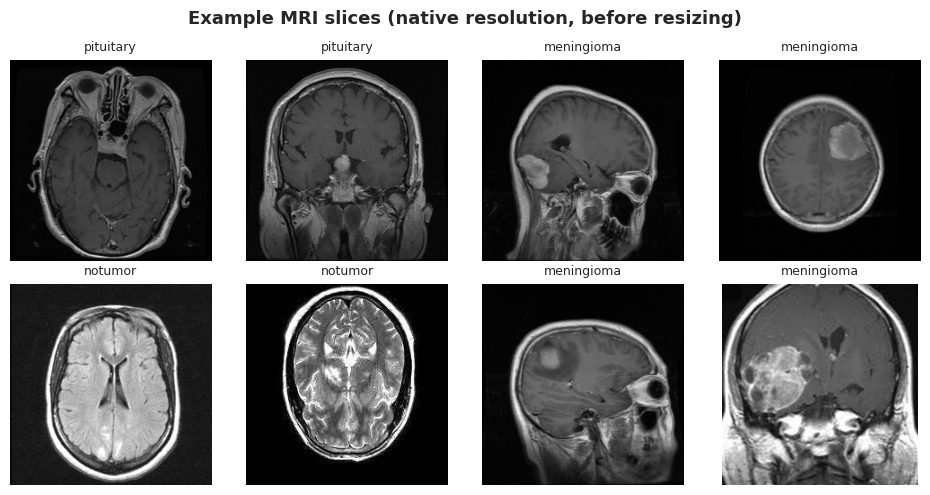

In [7]:
def show_examples(paths, labels, class_names, n=8):
    idx = np.random.RandomState(SEED).choice(len(paths), size=n, replace=False)
    fig, axes = plt.subplots(2, n // 2, figsize=(2.4 * (n // 2), 5))
    for ax, i in zip(axes.ravel(), idx):
        img = Image.open(paths[i]).convert("L")
        ax.imshow(img, cmap="gray")
        ax.set_title(class_names[labels[i]], fontsize=9)
        ax.axis("off")
    plt.suptitle("Example MRI slices (native resolution, before resizing)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_examples(train_paths_all, train_labels_all, class_names)

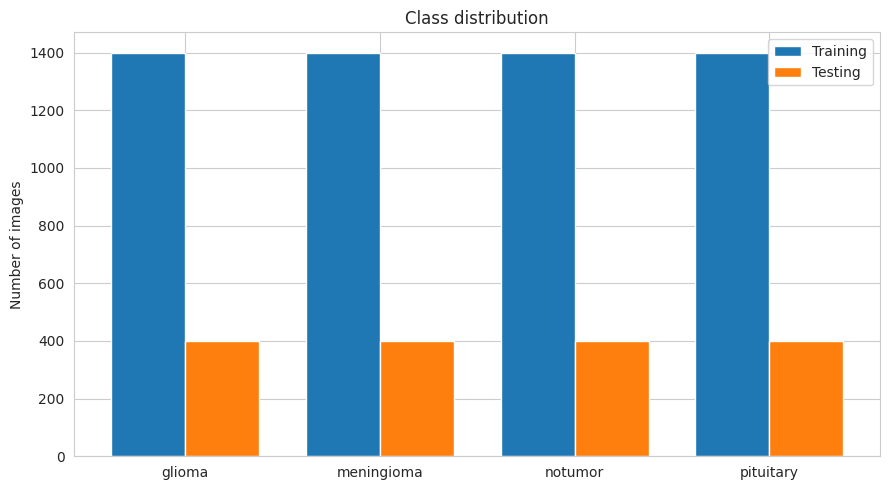

,class,training_count,testing_count
0,glioma,1400,400
1,meningioma,1400,400
2,notumor,1400,400
3,pituitary,1400,400


In [8]:
train_counts = Counter(train_labels_all)
test_counts = Counter(test_labels)

distribution = pd.DataFrame({
    "class": class_names,
    "training_count": [train_counts[i] for i in range(NUM_CLASSES)],
    "testing_count": [test_counts[i] for i in range(NUM_CLASSES)],
})

x = np.arange(NUM_CLASSES)
width = 0.38
plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, distribution["training_count"], width, label="Training")
plt.bar(x + width / 2, distribution["testing_count"], width, label="Testing")
plt.xticks(x, class_names)
plt.ylabel("Number of images")
plt.title("Class distribution")
plt.legend()
plt.tight_layout()
plt.show()

distribution

## 4. Stratified Train / Validation Split

Only the `Training` folder is split. The `Testing` folder is never touched until final evaluation.

In [9]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths_all,
    train_labels_all,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=train_labels_all,
)

print(f"Train samples     : {len(train_paths)}")
print(f"Validation samples: {len(val_paths)}")
print(f"Test samples      : {len(test_paths)}")

Train samples     : 4760
Validation samples: 840
Test samples      : 1600


## 5. Preprocessing and `tf.data` Pipelines for MobileNetV2

Two things are different here compared to the from-scratch CNN's pipeline:

- **Grayscale to RGB.** MobileNetV2 was pretrained on 3-channel color ImageNet photos, so a single-channel
  MRI slice needs to become a 3-channel image before it goes in. `tf.image.grayscale_to_rgb` does exactly
  that — it duplicates the one channel into three identical ones. The pretrained filters still see *the
  same MRI intensities* in all three channels; we're just satisfying MobileNetV2's expected input shape.
- **MobileNetV2's own preprocessing, not manual rescaling.** The from-scratch CNN rescaled pixels with a
  `Rescaling(1/255)` layer built into the model. MobileNetV2 instead expects its own specific
  normalization (`keras.applications.mobilenet_v2.preprocess_input`, which scales pixels to `[-1, 1]`) —
  the same idea as Session 16's `preprocess_input` calls for each architecture there.

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

def mobilenet_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=1, expand_animations=False)
    image.set_shape([None, None, 1])
    image = tf.image.resize(image, IMG_SIZE, method="bilinear")
    image = tf.image.grayscale_to_rgb(image)                       # 1 channel -> 3 identical channels
    image = keras.applications.mobilenet_v2.preprocess_input(image)  # MobileNetV2's own normalization
    return image, label

def make_dataset(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(mobilenet_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

mobilenet_train_ds = make_dataset(train_paths, train_labels, shuffle=True)
mobilenet_val_ds = make_dataset(val_paths, val_labels, shuffle=False)
mobilenet_test_ds = make_dataset(test_paths, test_labels, shuffle=False)

print(mobilenet_train_ds)

I0000 00:00:1790189720.578484      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790189720.581370      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


## 6. Shared Plotting and Reporting Helpers

The remaining sections train and evaluate the **single frozen-backbone transfer-learning model**.
These helpers keep the plotting, evaluation, and confusion-matrix code separate from the model
definition.

In [11]:
results = {}      # every model's final scores, filled in by hand after each model's cells
histories = {}    # every model's per-epoch history, same pattern


def plot_all_metrics(history, title):
    metric_names = [k for k in history.history if not k.startswith("val_")]
    n = len(metric_names)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, metric in zip(axes, metric_names):
        ax.plot(history.history[metric], label="train", color="#38BDF8", lw=2)
        val_key = f"val_{metric}"
        if val_key in history.history:
            ax.plot(history.history[val_key], label="validation", color="#F59E0B", lw=2)
        ax.set_title(metric)
        ax.set_xlabel("epoch")
        ax.legend()
    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


def evaluate_and_report(model, test_ds, y_true, title):
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    print(f"=== {title}: test set ===")
    print(f"loss: {test_loss:.4f}   accuracy: {test_acc:.4f}\n")

    y_prob = model.predict(test_ds, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))
    return test_loss, test_acc, y_pred, y_prob


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{title} — confusion matrix")
    plt.xlabel("predicted")
    plt.ylabel("actual")
    plt.tight_layout()
    plt.show()

## 7. MobileNetV2 Transfer Learning — Frozen Pretrained Backbone

We load MobileNetV2 without its ImageNet classification head and freeze **every layer**. Its pretrained
weights will not change during training. A small classification head is then added for the four MRI
classes.

In [12]:
# Load MobileNetV2 pretrained on ImageNet.
# include_top=False removes ImageNet's original 1000-class classifier.
mobilenet_tl_base = keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMG_SIZE, 3),
)

# Freeze the entire pretrained backbone.
mobilenet_tl_base.trainable = False

print("Backbone layers:", len(mobilenet_tl_base.layers))
print("Backbone parameters:", mobilenet_tl_base.count_params())
print("Trainable backbone layers:",
      sum(layer.trainable for layer in mobilenet_tl_base.layers))
print("Backbone trainable:", mobilenet_tl_base.trainable)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Backbone layers: 154
Backbone parameters: 2257984
Trainable backbone layers: 0
Backbone trainable: False


### 7.1 Build the classifier head — `Sequential` + `Flatten`

Same building block as the from-scratch CNN: `keras.Sequential([...])`, a stack of layers listed top to
bottom. The only new idea is that the *first* layer in the stack is the whole pretrained MobileNetV2
backbone instead of a `Conv2D`. `Flatten` turns its output feature maps into a flat vector, then `Dropout`
and a `Dense(NUM_CLASSES, softmax)` do the actual 4-class classification.

(`mobilenet_tl_base.trainable = False`, set above, already keeps every one of the backbone's layers —
including its `BatchNormalization` layers — in inference mode and out of training. No extra step is
needed for that here.)

In [13]:
# Build the transfer-learning classifier.
# The MobileNetV2 backbone is frozen; only the Dropout/Dense head can learn.
mobilenet_tl_model = keras.Sequential(
    [
        mobilenet_tl_base,
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ],
    name="mobilenet_transfer",
)

mobilenet_tl_model.summary()

Model: "mobilenet_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │       250,884 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,508,868 (9.57 MB)

 Trainable params: 250,884 (980.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 7.2 Compile — only the head's weights are trainable

Multi-class classification with integer labels, so `sparse_categorical_crossentropy` — same loss the
from-scratch CNN used.

In [14]:
# Compile the transfer-learning model.
mobilenet_tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

mobilenet_tl_trainable = int(
    np.sum([np.prod(w.shape) for w in mobilenet_tl_model.trainable_weights])
)
mobilenet_tl_non_trainable = int(
    np.sum([np.prod(w.shape) for w in mobilenet_tl_model.non_trainable_weights])
)

print("Trainable parameters:", mobilenet_tl_trainable)
print("Non-trainable parameters:", mobilenet_tl_non_trainable)

# Safety check: the pretrained MobileNetV2 backbone must remain frozen.
assert mobilenet_tl_base.trainable is False
assert all(not layer.trainable for layer in mobilenet_tl_base.layers),     "A MobileNetV2 backbone layer is unexpectedly trainable." 

Trainable parameters: 250884
Non-trainable parameters: 2257984


### 7.3 Train Model 1 (transfer learning)

In [15]:
# Train only the newly added classification head.
tl_start = time.time()

mobilenet_tl_history = mobilenet_tl_model.fit(
    mobilenet_train_ds,
    validation_data=mobilenet_val_ds,
    epochs=EPOCHS_TL,
    verbose=2,
)

mobilenet_tl_train_time = time.time() - tl_start

print(f"Training time: {mobilenet_tl_train_time:.1f} seconds")
print("Backbone still frozen:",
      all(not layer.trainable for layer in mobilenet_tl_base.layers))

Epoch 1/10


2026-09-23 18:55:39.128702: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 18:55:39.264777: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1790189741.576262     134 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-09-23 18:55:58.817949: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 18:55:58.955103: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-o

149/149 - 54s - 365ms/step - accuracy: 0.8403 - loss: 1.7971 - val_accuracy: 0.8952 - val_loss: 1.1299
Epoch 2/10
149/149 - 5s - 33ms/step - accuracy: 0.9370 - loss: 0.5938 - val_accuracy: 0.9238 - val_loss: 1.0567
Epoch 3/10
149/149 - 5s - 33ms/step - accuracy: 0.9756 - loss: 0.1949 - val_accuracy: 0.9345 - val_loss: 0.7188
Epoch 4/10
149/149 - 5s - 33ms/step - accuracy: 0.9798 - loss: 0.1505 - val_accuracy: 0.9310 - val_loss: 0.7922
Epoch 5/10
149/149 - 5s - 33ms/step - accuracy: 0.9748 - loss: 0.2275 - val_accuracy: 0.9262 - val_loss: 1.0585
Epoch 6/10
149/149 - 6s - 37ms/step - accuracy: 0.9863 - loss: 0.0995 - val_accuracy: 0.9369 - val_loss: 0.8292
Epoch 7/10
149/149 - 5s - 34ms/step - accuracy: 0.9893 - loss: 0.0779 - val_accuracy: 0.9405 - val_loss: 0.8689
Epoch 8/10
149/149 - 5s - 35ms/step - accuracy: 0.9912 - loss: 0.0617 - val_accuracy: 0.9440 - val_loss: 0.7012
Epoch 9/10
149/149 - 5s - 36ms/step - accuracy: 0.9893 - loss: 0.0836 - val_accuracy: 0.9369 - val_loss: 0.9766
E

### 7.4 Training curves — every tracked metric, per epoch

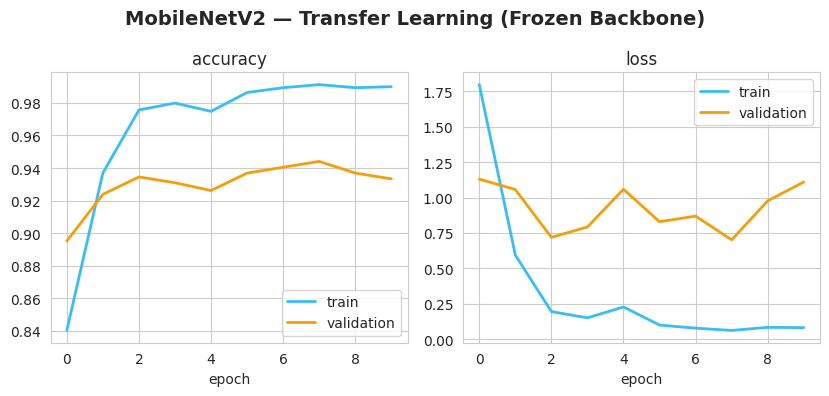

In [16]:
plot_all_metrics(
    mobilenet_tl_history,
    "MobileNetV2 — Transfer Learning (Frozen Backbone)"
)

### 7.5 Evaluate on the untouched test set

In [17]:
mobilenet_tl_loss, mobilenet_tl_acc, mobilenet_tl_y_pred, mobilenet_tl_y_prob = (
    evaluate_and_report(
        mobilenet_tl_model,
        mobilenet_test_ds,
        test_labels,
        "MobileNetV2 — Transfer Learning (Frozen Backbone)",
    )
)

=== MobileNetV2 — Transfer Learning (Frozen Backbone): test set ===
loss: 3.9487   accuracy: 0.9031

              precision    recall  f1-score   support

      glioma      0.944     0.720     0.817       400
  meningioma      0.788     0.920     0.849       400
     notumor      0.966     0.993     0.979       400
   pituitary      0.940     0.980     0.960       400

    accuracy                          0.903      1600
   macro avg      0.910     0.903     0.901      1600
weighted avg      0.910     0.903     0.901      1600



### 7.6 Confusion matrix

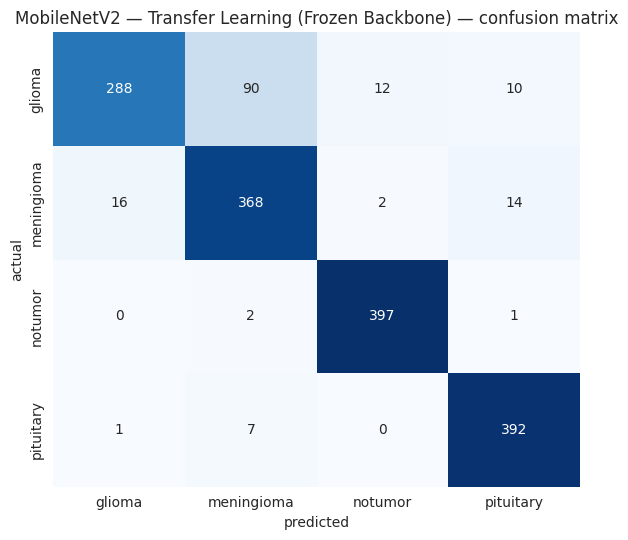

In [18]:
plot_confusion(
    test_labels,
    mobilenet_tl_y_pred,
    "MobileNetV2 — Transfer Learning (Frozen Backbone)"
)

In [19]:
results["MobileNetV2 (Transfer Learning)"] = dict(
    test_loss=mobilenet_tl_loss,
    test_acc=mobilenet_tl_acc,
    params=mobilenet_tl_trainable,
    train_time=mobilenet_tl_train_time,
)
histories["MobileNetV2 (Transfer Learning)"] = mobilenet_tl_history

pd.DataFrame(results).T

,test_loss,test_acc,params,train_time
MobileNetV2 (Transfer Learning),3.94873,0.903125,250884.0,100.495817


**Transfer-learning takeaway.** The MobileNetV2 feature extractor stayed frozen throughout training,
so all learning came from the newly initialized classification head. The final test-set metrics above
show how well these fixed ImageNet features transfer to the MRI classification task.

## 8. Save the Trained Transfer-Learning Model

The trained model is saved in both formats requested:

- **`.keras`** — the recommended native Keras format.
- **`.h5`** — HDF5 format for compatibility with workflows that still require it.

Both files contain the same trained transfer-learning model.

In [20]:
# Save the final trained transfer-learning model in both formats.
# The MobileNetV2 backbone remains frozen in the saved model configuration.
mobilenet_tl_model.save(KERAS_MODEL_PATH)
mobilenet_tl_model.save(H5_MODEL_PATH)

print("Saved Keras model:", KERAS_MODEL_PATH)
print("Saved H5 model   :", H5_MODEL_PATH)

# Verify that both files were created.
assert Path(KERAS_MODEL_PATH).exists()
assert Path(H5_MODEL_PATH).exists()

print(f"Keras file size: {Path(KERAS_MODEL_PATH).stat().st_size / (1024**2):.2f} MB")
print(f"H5 file size   : {Path(H5_MODEL_PATH).stat().st_size / (1024**2):.2f} MB")

Saved Keras model: mobilenetv2_mri_transfer_learning.keras
Saved H5 model   : mobilenetv2_mri_transfer_learning.h5
Keras file size: 12.04 MB
H5 file size   : 11.83 MB


## 9. Final Notes

This notebook intentionally stops after **transfer learning**. There is no second model and no
fine-tuning stage.

The final trained model is available as:
- `mobilenetv2_mri_transfer_learning.keras`
- `mobilenetv2_mri_transfer_learning.h5`

Because the backbone is frozen, the model's pretrained MobileNetV2 weights are not updated by this
training run.